<a href="https://colab.research.google.com/github/samarthbharadwaj/internship/blob/main/QML_Signal_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
pip install qiskit

In [19]:
pip normalize

ERROR: unknown command "normalize"


In [20]:
pip install qasm

In [21]:
pip install tensorflow

In [22]:
pip install qubits


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 52.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.1/55.1 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.5/145.5 kB 9.9 MB/s eta 0:00:00
  Created wheel for pysynphot: filename=pysynphot-2.0.0-cp312-cp312-linux_x86_64.whl size=6686165 sha256=47f399911110bdd2a7be06ca935fadb873cb30c76157c8c532814e21108ca2ed
  Stored in directory: /root/.cache/pip/wheels/6e/bc/b6/e473debcbaa65aef7d0a7fc417d8550ad6b86a695f0c522551
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13706 sha256=8d0562144c4ceb1c0a07cd654cb45985a86f956bcc3dc7f7f648afe5700452ca
  Stored in directory: /root/.cach

In [23]:
pip install numpy

In [ ]:
pip install signal processing

ERROR: Could not find a version that satisfies the requirement signal (from versions: none)
ERROR: No matching distribution found for signal


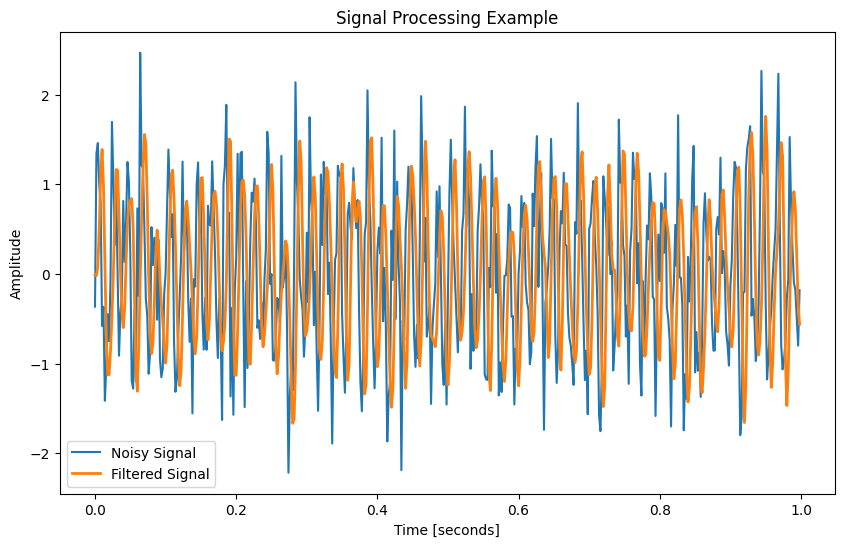

In [24]:
# Classical signal processing + quantum ML integration

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter, freqz

# Example: Generate a test signal (sine + noise)
fs = 500.0       # Sampling frequency
t = np.arange(0, 1.0, 1/fs)
signal = np.sin(2*np.pi*50*t) + 0.5*np.random.randn(len(t))

# Design a low-pass filter
def butter_lowpass(cutoff, fs, order=5):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return b, a

def butter_lowpass_filter(data, cutoff, fs, order=5):
    b, a = butter_lowpass(cutoff, fs, order=order)
    y = lfilter(b, a, data)
    return y

# Apply filter
cutoff = 100.0  # cutoff frequency in Hz
filtered_signal = butter_lowpass_filter(signal, cutoff, fs)

# Plot original vs filtered
plt.figure(figsize=(10,6))
plt.plot(t, signal, label='Noisy Signal')
plt.plot(t, filtered_signal, label='Filtered Signal', linewidth=2)
plt.xlabel('Time [seconds]')
plt.ylabel('Amplitude')
plt.legend()
plt.title('Signal Processing Example')
plt.show()

In [25]:
pip install sampler

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 556.5/556.5 kB 9.3 MB/s eta 0:00:00
  Created wheel for sampler: filename=sampler-0.2.0-py3-none-any.whl size=2952 sha256=9b4cc1e1586ce4015e5c974a722678e5f81caa4935aef991aa0dc133ccb65f4a
  Stored in directory: /root/.cache/pip/wheels/6f/b4/fd/5f97ba75d5f7cc2a61b17c69fa174eba2101ce49a368050c10
Successfully built sampler


In [26]:
pip install primitives

In [27]:
pip install qiskit-machine-learning

In [28]:
pip install qiskit_sampler

ERROR: Could not find a version that satisfies the requirement qiskit_sampler (from versions: none)
ERROR: No matching distribution found for qiskit_sampler


/tmp/ipykernel_1951/1952467253.py:48: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(feature_dimension=2, reps=1, entanglement='linear')


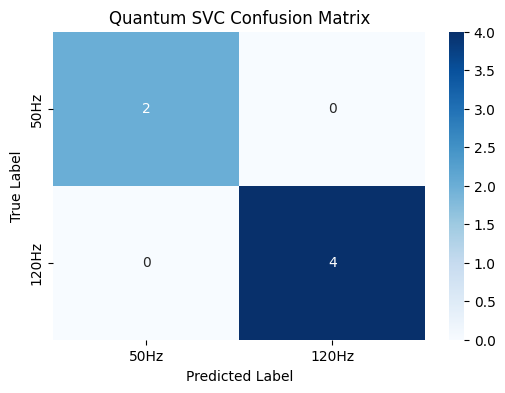

Quantum SVC Accuracy: 1.0


In [29]:
import os
os.environ["QISKIT_SUPPRESS_1_0_IMPORT_ERROR"] = "1"

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import butter, lfilter
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

# Qiskit imports
from qiskit import QuantumCircuit
from qiskit.circuit.library import ZZFeatureMap
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.algorithms.classifiers import QSVC
from qiskit_machine_learning.utils import algorithm_globals

# Use StatevectorSampler (V2) and ComputeUncompute for Qiskit 1.0+
from qiskit.primitives import StatevectorSampler
from qiskit_algorithms.state_fidelities import ComputeUncompute

algorithm_globals.random_seed = 42

fs = 500.0
t = np.arange(0, 1.0, 1/fs)

def butter_lowpass_filter(data, cutoff=100.0, fs=500.0, order=5):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return lfilter(b, a, data)

def generate_data(n_samples=10):
    X_list = []
    y_list = []
    for _ in range(n_samples):
        sig0 = np.sin(2*np.pi*50*t) + 0.5*np.random.randn(len(t))
        f0 = butter_lowpass_filter(sig0)
        X_list.append([np.mean(f0), np.var(f0)])
        y_list.append(0)
        sig1 = np.sin(2*np.pi*120*t) + 0.5*np.random.randn(len(t))
        f1 = butter_lowpass_filter(sig1)
        X_list.append([np.mean(f1), np.var(f1)])
        y_list.append(1)
    return np.array(X_list), np.array(y_list)

X, y = generate_data(n_samples=10)
feature_map = ZZFeatureMap(feature_dimension=2, reps=1, entanglement='linear')

# Initialize StatevectorSampler for Qiskit 1.x compatibility
sampler = StatevectorSampler()
fidelity = ComputeUncompute(sampler=sampler)
qkernel = FidelityQuantumKernel(feature_map=feature_map, fidelity=fidelity)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

qsvc = QSVC(quantum_kernel=qkernel)
qsvc.fit(X_train, y_train)

y_pred = qsvc.predict(X_test)

# Display output as a Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['50Hz', '120Hz'], yticklabels=['50Hz', '120Hz'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Quantum SVC Confusion Matrix')
plt.show()

print("Quantum SVC Accuracy:", accuracy_score(y_test, y_pred))

Pearson Correlation between Mean and Variance: -0.1514


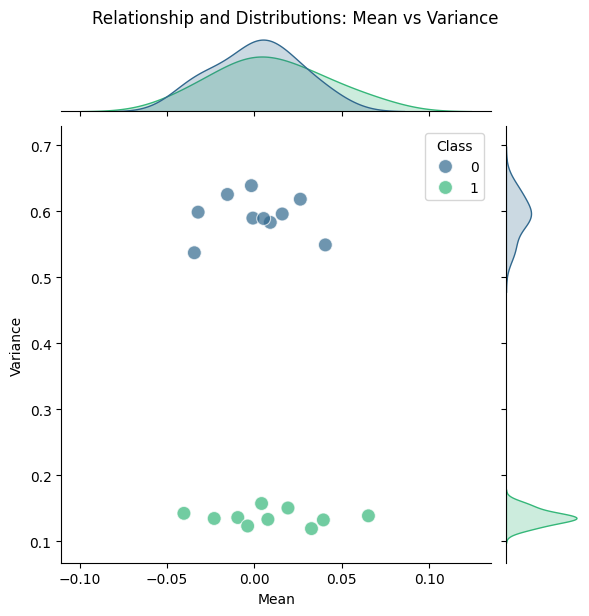

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate Pearson correlation
correlation = df_features[['Mean', 'Variance']].corr().iloc[0, 1]
print(f"Pearson Correlation between Mean and Variance: {correlation:.4f}")

# Create a joint plot to see distributions and relationship
g = sns.jointplot(data=df_features, x='Mean', y='Variance', hue='Class', palette='viridis', kind='scatter', s=100, alpha=0.7)
g.fig.suptitle('Relationship and Distributions: Mean vs Variance', y=1.02)
plt.show()

In [14]:
from qiskit.circuit.library import TwoLocal
from qiskit.circuit import ParameterVector
import matplotlib.pyplot as plt

# Define parameters for our 2-dimensional input data
# This ensures the kernel knows exactly which parameters are for data
user_params = ParameterVector("x", 2)

# Create a circuit that uses these parameters
# We'll manually build a multi-layer entangling circuit
complex_feature_map = QuantumCircuit(2)
complex_feature_map.ry(user_params[0], 0)
complex_feature_map.rz(user_params[1], 1)
complex_feature_map.cx(0, 1)
complex_feature_map.ry(user_params[1], 0)
complex_feature_map.rz(user_params[0], 1)

print("Custom Complex Feature Map:")
print(complex_feature_map.draw())

# Re-initialize the Quantum Kernel
fidelity = ComputeUncompute(sampler=StatevectorSampler())
qkernel_complex = FidelityQuantumKernel(feature_map=complex_feature_map, fidelity=fidelity)

# Re-fit the QSVC
qsvc_complex = QSVC(quantum_kernel=qkernel_complex)
qsvc_complex.fit(X_train, y_train)

# Predict and evaluate
y_pred_complex = qsvc_complex.predict(X_test)
print(f"\nComplex Quantum SVC Accuracy: {accuracy_score(y_test, y_pred_complex)}")

Custom Complex Feature Map:
     ┌──────────┐     ┌──────────┐
q_0: ┤ Ry(x[0]) ├──■──┤ Ry(x[1]) ├
     ├──────────┤┌─┴─┐├──────────┤
q_1: ┤ Rz(x[1]) ├┤ X ├┤ Rz(x[0]) ├
     └──────────┘└───┘└──────────┘

Complex Quantum SVC Accuracy: 0.3333333333333333


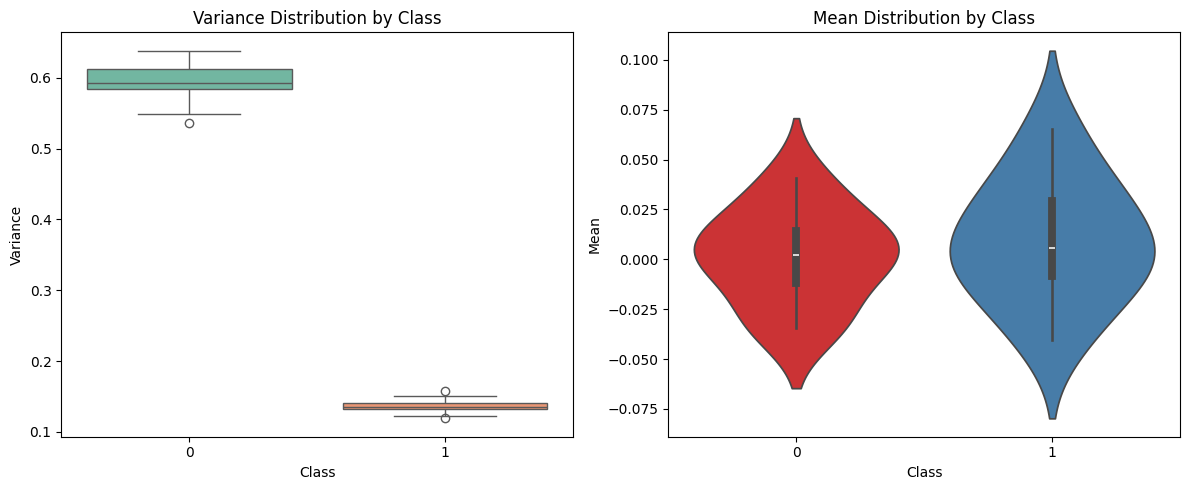

In [16]:
plt.figure(figsize=(12, 5))

# Subplot 1: Boxplot of Variance
plt.subplot(1, 2, 1)
sns.boxplot(data=df_features, x='Class', y='Variance', hue='Class', palette='Set2')
plt.title('Variance Distribution by Class')

# Subplot 2: Violin plot of Mean
plt.subplot(1, 2, 2)
sns.violinplot(data=df_features, x='Class', y='Mean', hue='Class', palette='Set1')
plt.title('Mean Distribution by Class')

plt.tight_layout()
plt.show()

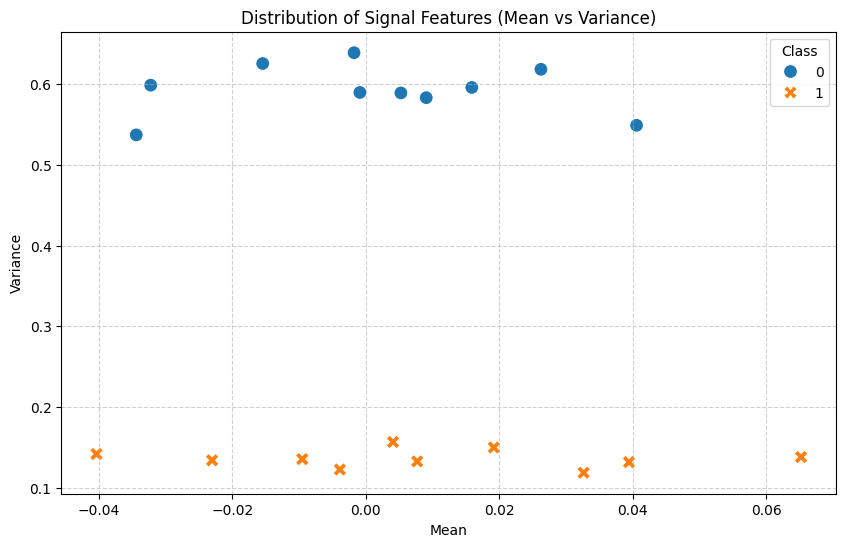

Feature Statistics by Class:


Mean                                                              \
      count      mean       std       min       25%       50%       75%   
Class                                                                     
0      10.0  0.001237  0.023920 -0.034399 -0.012025  0.002197  0.014190   
1      10.0  0.009158  0.031183 -0.040358 -0.008109  0.005905  0.029292   

                Variance                                                    \
            max    count      mean       std       min       25%       50%   
Class                                                                        
0      0.040592     10.0  0.592187  0.031626  0.536836  0.584319  0.592436   
1      0.065249     10.0  0.136526  0.011415  0.119019  0.132379  0.135096   

                           
            75%       max  
Class                      
0      0.613061  0.638459  
1      0.141235  0.157058

In [15]:
import pandas as pd
import seaborn as sns

# Create a DataFrame for easier visualization
df_features = pd.DataFrame(X, columns=['Mean', 'Variance'])
df_features['Class'] = y.astype(str)

# Visualize the distribution of the features
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_features, x='Mean', y='Variance', hue='Class', style='Class', s=100)
plt.title('Distribution of Signal Features (Mean vs Variance)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Print basic statistics
print("Feature Statistics by Class:")
display(df_features.groupby('Class').describe())